# Opdrachten - logistic regression

Logistische regressie is een bijzonder populaire classificatietechniek. Enerzijds door zijn eenvoud en relatief lage eisen die het stelt in termen van rekenkracht. In veel gevallen is de performantie qua accuracy vergelijkbaar (en soms beter) dan gecompliceerdere algoritmes zoals de support vector machines.
Daarnaast heeft logistische regressie het voordeel dat het getrainde model een voorspelling doet in termen van de kans dat de input tot een bepaalde klasse behoort. Uit deze kans kan je afleiden hoe overtuigd het model is van de gemaakte voorspelling.

Het is de bedoeling om via enkele classificatieopdrachten inzicht te verkrijgen in:
- Correct trainen en het uitvoeren van hyperparameter tuning bij logistische regressie.
- Classificaties kunnen uitvoeren via logistische regressie.
- Feature engineering uitvoeren.
- Interpreteren van de verschillende performance metrics: accuracy, recall, precision, f1-score, ROC.
- Weten wanneer je te maken hebt met overfitting en underfitting en de juiste bijstellingen kunnen doen.


In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns

## Opdracht 1: Classificatie van wijn

Het doel van deze classificatie is te kunnen achterhalen op basis van chemische parameters van welke wijnboer (cultivar) een wijn afkomstig is.

Gebruik hiervoor de dataset *wine_data.csv*. De features bevinden zich in de eerste kolommen van de dataset. De targets/outputs zijn in de laatste kolom te vinden.

### Inlezen van de dataset en vooranalyse

In [5]:
# inlezen van de data
dataset = pd.read_csv('data/wine_data.csv')
dataset.head(10)

,inputs Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,flavanoids,NonflavanoidsPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline,Cultivar
0,12.08,1.33,2.30,23.6,70,2.20,1.59,0.42,1.38,1.74,1.07,3.21,625,1
1,12.08,1.13,2.51,24.0,78,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630,1
2,12.37,1.17,1.92,19.6,78,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510,1
3,13.11,1.01,1.70,15.0,78,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502,1
4,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580,1
5,12.25,1.73,2.12,19.0,80,1.65,2.03,0.37,1.63,3.40,1.00,3.17,510,1
6,12.69,1.53,2.26,20.7,80,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495,1
7,12.77,3.43,1.98,16.0,80,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372,1
8,13.88,5.04,2.23,20.0,80,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415,2
9,12.08,1.83,2.32,18.5,81,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480,1


In [6]:
dataset.shape

(178, 14)

**TAAK: Bepaal het aantal klasses. Met andere woorden, hoeveel verschillende wijnboeren zijn er?**

In [11]:
dataset.Cultivar.nunique()

3

**TAAK: Hoeveel wijnen van elke wijnboer steken in de dataset? Is de dataset gebalanceerd?**<p> Gebalanceerd wil zeggen dat elke klasse ongeveer even sterk in de dataset aanwezig is.</p>

In [12]:
dataset.Cultivar.value_counts()

Cultivar
1    71
0    59
2    48
Name: count, dtype: int64

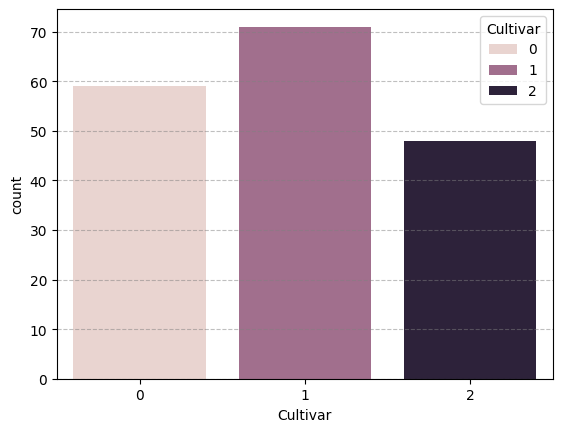

In [21]:
sns.countplot(data=dataset, x='Cultivar', hue='Cultivar')
plt.grid(axis='y', linestyle='--', color='gray', alpha=0.5)
plt.show()

**TAAK: Bepaal de statistische kerngetallen van de verschillende features en targets.**<p> Gebruik hiervoor de *describe* functie. Gebruik de resultaten om na te gaan of er mogelijks ontbrekende waarden, uitschieters of onrealistische waarden zijn.</p>

In [13]:
dataset.describe()

,inputs Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,flavanoids,NonflavanoidsPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline,Cultivar
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   inputs Alcohol        178 non-null    float64
 1   MalicAcid             178 non-null    float64
 2   Ash                   178 non-null    float64
 3   AlcalinityOfAsh       178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   TotalPhenols          178 non-null    float64
 6   flavanoids            178 non-null    float64
 7   NonflavanoidsPhenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   ColorIntensity        178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280/OD315           178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Cultivar              178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


<Axes: >

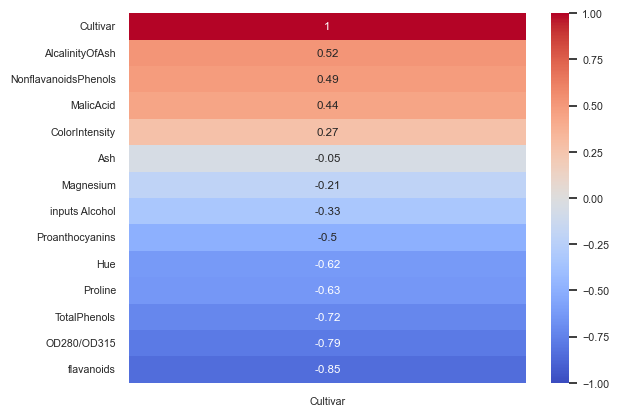

In [31]:
sns.set_theme(font_scale=0.7)
sns.heatmap(dataset.corr(numeric_only=True)["Cultivar"].sort_values(ascending=False).to_frame(), cmap="coolwarm", annot=True, vmin=-1, vmax=1)

### Preprocessing en opsplitsen van de dataset

**TAAK: Splits de dataset in features en targets**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = dataset.drop("Cultivar", axis=1), dataset["Cultivar"]

**TAAK: Creëer een trainingset en een testset**. <p>Zorg dat je 70 wijnen in de test set zitten hebt. Gebruik hiervoor train_test_split functie.</p>

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.39, random_state=42)
X_test.shape


(70, 13)

**TAAK: Normaliseer de dataset**. <p>Zorg er dus voor dat de features op een gelijke schaalverdeling staan. Voor het normaliseren kan gebruik gemaakt worden van de *preprocessing.StandardScaler()*. </p>

In [39]:
# Standardscaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)


### Trainen van een logistic regression classifier en testen van het bekomen model

**TAAK: Train een logistic regression classifier op de training data.** <p>(http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)  
Kies C=1 als startwaarde. </p>

Test het getrainde model op de test set. Bepaal hierbij de confusion matrix, de accuracy en het classification report. Wat zijn de bevindingen?

Probeer indien nodig de performantie van de classifier te verhogen door de parameter C  aan te passen, class_weight aan te passen of een andere solver toe te passen. 
Schrijf de conclusies neer. 

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model = LogisticRegression()

In [44]:
model.fit(scaled_X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = model.predict(scaled_X_test)
confusion_matrix(y_test, y_pred)

array([[18,  0,  0],
       [ 0, 27,  1],
       [ 0,  0, 24]])

In [51]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

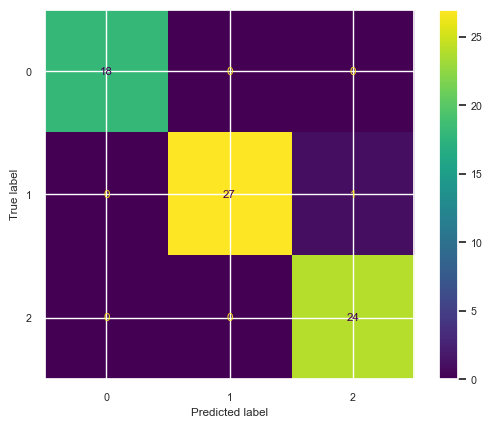

In [52]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.96      0.98        28
           2       0.96      1.00      0.98        24

    accuracy                           0.99        70
   macro avg       0.99      0.99      0.99        70
weighted avg       0.99      0.99      0.99        70



Conclusies?

default waardes waren al goed genoeg:

```
class sklearn.linear_model.LogisticRegression(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)[source]
```

**TAAK: Voorspel aan de hand van het getrainde model**

Voorspel van welke wijnboer een wijn afkomstig is met volgende samenstelling:

inputs Alcohol: 13.52 - 
MalicAcid: 2.05 - 
Ash: 2.20 - 
AlcalinityOfAsh: 17.3 - 
Magnesium: 120 - 
TotalPhenols: 2.60 - 
flavanoids: 3.52 - 
NonflavanoidsPhenols: 0.30 - 
Proanthocyanins: 2.28 - 
ColorIntensity: 7.80 - 
Hue: 0.77 - 
OD280/OD315: 2.90 - 
Proline: 862


Geef ook de overtuiging van het model weer dat de wijn van die bepaalde wijnboer afkomstig is.

In [55]:
wine = np.array([[13.52, 2.05, 2.20, 17.3, 120, 2.60, 3.52, 0.30, 2.28, 7.80, 0.77, 2.90, 862]])
wine_scaled = scaler.transform(wine)
model.predict(wine_scaled)

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
model.predict_proba(wine_scaled)
# de hoogste getal is de probabiliteit van de juiste predictie (0.96)

array([[0.96337055, 0.02031738, 0.01631208]])

**TAAK: Voeg extra features toe: kijk of je een beter resultaat kan bekomen via polynomiale regressie**
<p>Bepaal opnieuw alle metrics en vergelijk.  Kijk welke regularisatie het beste resultaat geeft.</p>

In [ ]:
# Pff, dit is een aparte oefening (zie PolyReg)

## Opdracht 2: Diabetes

Het bestand *diabetes.csv* bevat medische gegevens van meer dan 300 personen waarbij telkens geweten is of de persoon al dan niet diabetes heeft.
Train nu een logic regression model dat op basis van de features een zo goed mogelijke predictie kan doen of iemand al dan niet diabetes heeft.

### Inlezen van de dataset en vooranalyse

In [6]:
#Inlezen van de dataset
dataset = pd.read_csv('../DATA/diabetes.csv')
dataset.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


**TAAK: Controleer of de dataset inconsistenties of foute waarden bevat. Gebruik listwise deletion.** <p>Dit betekent dat je alle gegevens van een persoon uit de dataset verwijdert van zodra er 1 feature foutief is of ontbreekt.</p>

**TAAK: Bepaal de verdeling van het aantal personen met diabetes ten opzichte van het aantal personen zonder. Is de dataset gebalanceerd?**

**TAAK: Bepaal de statistische kerngetallen van de verschillende features en target. Gebruik hiervoor de *describe* functie.**

### Preprocessing en opsplitsen van de dataset

**TAAK: Splits de dataset in features en targets**

**TAAK: Creëer een trainingset en een testset. Zorg dat er 100 patiënten in de testset steken.** 

**TAAK: Normaliseer de dataset**. <p>Zorg er dus voor dat de features op een gelijke schaalverdeling staan. Voor het normaliseren kan gebruik gemaakt worden van de *preprocessing.StandardScaler()*. </p>

### Trainen van een logistic regression classifier en testen van het bekomen model

**TAAK: Train een logistic regression classifier op de training data. Kies C=1 als startwaarde. Mocht de dataset niet gebalanceerd zijn (de ene klasse komt frequenter voor dan de andere klasse) dan kan je bij de creatie van het logistic regression model de parameter class_weight='balanced' meegeven.** 

**Test het getrainde model op de test set. Bepaal hierbij de confusion matrix, de accuracy en het classification report. Wat zijn de bevindingen? Probeer ook verschillende solvers uit. Bepaal ook telkens de ROC en formuleer conclusies.**

**Pr**TAAK: Voorspel of een gezwel met onderstaande parameters goedaardig of kwaadaardig is.**Voorspel

radius_mean: 17.99 |
texture_mean: 10.38 |
perimeter_mean: 122.8 |
area_mean: 1001 |
smoothness_mean: 0.1184 |
compactness_mean: 0.2776 |
concavity_mean: 0.3001 |
concave points_mean: 0.1471 |
symmetry_mean: 0.2419 |
fractal_dimension_mean: 0.07871 |
radius_se: 1.095 |
texture_se: 0.9053 |
perimeter_se: 8.589 |
area_se:153.4 |
smoothness_se:0.006399 |
compactness_se: 0.04904 |
concavity_se: 0.05373 |
concave points_se: 0.01587 |
symmetry_se: 0.03003 |
fractal_dimension_se: 0.006193 |
radius_worst: 25.38 |
texture_worst: 17.33 |
perimeter_worst: 184.6 |
area_worst: 2019 |
smoothness_worst: 0.1622 |
compactness_worst: 0.6656 |
concavity_worst: 0.7119 |
concave points_worst: 0.2654 |
symmetry_worst: 0.4601 |
fractal_dimension_worst: 0.1189 |obeer de performantie van de classifier te verhogen door de parameter C te veranderen.**

### Feature engineering
**TAAK: Creeër hogere orde features door gebruik te maken van *preprocessing.PolynomialFeatures*.** 

Deze functie zal automatische hogere orde features aanmaken door het combineren van de aanwezige features. Heb je bijvoorbeeld drie features, zijnde A, B en C dan worden bij de keuze van een derde orde PolynomialFeatures volgende nieuwe features bijgemaakt:
$A^3, B^3,C^3,A^2B,A^2C,AB^2, B^2C,...$

Experimenteer met verschillende ordes en gebruik de regularisatieparameter C om de performantie te verhogen.

**Opgepast**: het kiezen van een te hoge orde zorgt voor een exponentiële toename aan features waardoor de logistic regression classifier niet meer binnen aanvaardbare tijd getraind kan worden. Advies is om niet hoger te gaan dan 4de orde.

In [7]:
# Toevoegen van extra features


**TAAK: Wat zijn de bevindingen? Formuleer een conclusie.** <p>Bespreek hierin de performantie van de getrainde modellen. Wat is de invloed van de parameter C en van het aantal features? Heb je te maken gehad met underfitting en overfitting en hoe heb je dit bepaald? Welke accuracy werd bekomen en hoe zit het met de Recall en Precision? Is de grootte van de trainingset voldoende?</p>

**TAAK: Voorspel aan de hand van het getrainde model**

Voorspel of iemand met onderstaande medische parameters als dan niet diabetes heeft. Geef ook de zekerheid van het model weer (kansen dat de patiënt tot een bepaalde klasse behoort).

Pregnancies: 2 -
Glucose: 132 -
BloodPressure: 74 - 
SkinThickness: 20 - 
Insulin: 21 - 
BMI: 24.3 - 
DiabetesPedigreeFunction: 128 - 
Age: 37

## Opdracht 3: Kankerdetectie

**TAAK: Train een model om te voorspellen of een bepaalde tumor goedaardig (benign) of kwaadaardig (malignant) is.**
Gebruik daarvoor de dataset '*cancer.csv*'

Baseer je op de methodieken uit voorgaande opdrachten om tot een zo goed mogelijk resultaat te komen. 
**Bespreek** telkens de gemaakte keuzes en resultaten en kom tot een duidelijk besluit.

Tip: een classifier kan enkel maar getraind worden met numerieke waarden. Vervang daarom bij de feature diagnose de twee klasses die voorkomen door 0 en 1, waarbij 0 staat voor goedaardig en 1 voor kwaadaardig.


In [8]:
# Toevoegen van extra features

**TAAK: Voorspel of een gezwel met onderstaande parameters goedaardig of kwaadaardig is.**

radius_mean: 17.99 |
texture_mean: 10.38 |
perimeter_mean: 122.8 |
area_mean: 1001 |
smoothness_mean: 0.1184 |
compactness_mean: 0.2776 |
concavity_mean: 0.3001 |
concave points_mean: 0.1471 |
symmetry_mean: 0.2419 |
fractal_dimension_mean: 0.07871 |
radius_se: 1.095 |
texture_se: 0.9053 |
perimeter_se: 8.589 |
area_se:153.4 |
smoothness_se:0.006399 |
compactness_se: 0.04904 |
concavity_se: 0.05373 |
concave points_se: 0.01587 |
symmetry_se: 0.03003 |
fractal_dimension_se: 0.006193 |
radius_worst: 25.38 |
texture_worst: 17.33 |
perimeter_worst: 184.6 |
area_worst: 2019 |
smoothness_worst: 0.1622 |
compactness_worst: 0.6656 |
concavity_worst: 0.7119 |
concave points_worst: 0.2654 |
symmetry_worst: 0.4601 |
fractal_dimension_worst: 0.1189 |
